In [25]:
import pandas as pd
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN
import matplotlib.pyplot as plt
import os

In [26]:
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

In [27]:
t = np.arange(0, 2000)
X = np.sin(0.01 * t)

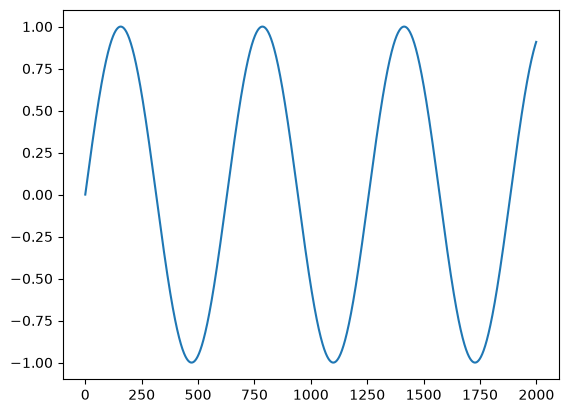

In [28]:
plt.plot(X)

In [29]:
X[:10]

array([0.        , 0.00999983, 0.01999867, 0.0299955 , 0.03998933,
       0.04997917, 0.05996401, 0.06994285, 0.07991469, 0.08987855])

In [30]:
X_train, X_test = X[:1500], X[1500:]

In [31]:
model = Sequential()
model.add(SimpleRNN(units=64, activation='tanh'))
model.add(Dense(1))

In [32]:
model.compile(loss='mean_absolute_error', optimizer='adam')

In [33]:
XT, yT = [], []
for i in range(len(X_train) - 15):
    d = i + 15
    XT.append(X_train[i:d,])
    yT.append(X_train[d])

In [34]:
Xt, yt = [], []
for i in range(len(X_test) - 15):
    d = i + 15
    Xt.append(X_test[i:d,])
    yt.append(X_test[d])

In [35]:
XT = np.array(XT)
Xt = np.array(Xt)

In [36]:
XT.shape

(1485, 15)

In [37]:
XT[2]

array([0.01999867, 0.0299955 , 0.03998933, 0.04997917, 0.05996401,
       0.06994285, 0.07991469, 0.08987855, 0.09983342, 0.1097783 ,
       0.11971221, 0.12963414, 0.13954311, 0.14943813, 0.15931821])

In [38]:
XT = np.reshape(XT, (XT.shape[0], XT.shape[1], 1))
Xt = np.reshape(Xt, (Xt.shape[0], Xt.shape[1], 1))

In [39]:
XT.shape

(1485, 15, 1)

In [42]:
XT[1]

array([[0.00999983],
       [0.01999867],
       [0.0299955 ],
       [0.03998933],
       [0.04997917],
       [0.05996401],
       [0.06994285],
       [0.07991469],
       [0.08987855],
       [0.09983342],
       [0.1097783 ],
       [0.11971221],
       [0.12963414],
       [0.13954311],
       [0.14943813]])

In [43]:
yT = np.array(yT)
yt = np.array(yt)

In [44]:
model.fit(XT, yT, epochs=100, batch_size=20)

Epoch 1/100


I0000 00:00:1783794433.071832  122844 service.cc:153] XLA service 0x7eace802f9e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1783794433.071851  122844 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 6GB Laptop GPU, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1783794433.107967  122844 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1783794433.236252  122844 cuda_dnn.cc:461] Loaded cuDNN version 92400
I0000 00:00:1783794433.250868  122844 dot_merger.cc:481] Merging Dots in computation: sequential_4_1_simple_rnn_4_1_while_body_1250_grad_1441_const_0__.15.clone.clone.clone.clone.clone
I0000 00:00:1783794433.262616  122844 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of 

59/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0745

I0000 00:00:1783794435.157052  122844 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
I0000 00:00:1783794435.379265  122841 dot_merger.cc:481] Merging Dots in computation: sequential_4_1_simple_rnn_4_1_while_body_1250_grad_1441_const_0__.15.clone.clone.clone.clone.clone


75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0622
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0123
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0146
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0085
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0095
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0064
Epoch 7/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0061
Epoch 8/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0086
Epoch 9/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0049
Epoch 10/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0037
Epoch 11/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0110
Epoch 12/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0060
Epoch 13/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0051
Epoch 14/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0044
Epoch 15/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0054
Epoch 16/100
75

In [45]:
model.evaluate(Xt, yt)

I0000 00:00:1783794525.030899  122841 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1783794525.542819  130821 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_12', 12 bytes spill stores, 12 bytes spill loads



16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0032


0.003239563899114728

In [46]:
XTPredicted = model.predict(XT)
XtPredicted = model.predict(Xt)
XFinal = np.concatenate([XTPredicted, XtPredicted], axis=0)

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


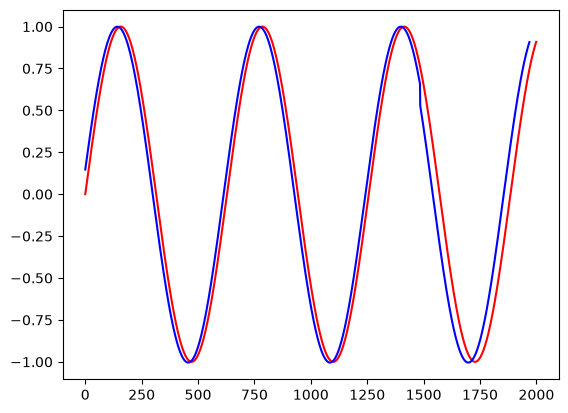

In [47]:
plt.plot(X, color='red')
plt.plot(XFinal, color='blue')